# Personality Traits and Decision Making: Exploring Behaviour Through MBTI Personality Data
---
### Opening Question
**Which personality types are most common? Do demographic factors or interests relate to personality differences?**

### Objective
This project investigates personality patterns, behavioural tendencies, demographic influences, and decision making preferences using MBTI personality data. Instead of just listing statistics, I want to find meaningful relationships within the dataset.

The goal is to understand how personality traits are distributed, whether demographics [like age, gender, education] matter, which interests attract specific types, and which personality dimensions show the strongest connections.

### Dataset Overview
- **Source**: MBTI dataset extracted from Kaggle.
- **Variables**: Age, Gender, Education, Introversion Score, Sensing Score, Thinking Score, Judging Score, Interest, Personality.
- **Analysis Approach**: Exploratory Data Analysis [EDA] using visualisations, summary statistics, correlations, and cross tabulations.


In [104]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# set visualisation style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 10

In [105]:
primary = "#00796B"   
secondary = "#80CBC4" 

# gradient
gradient = ["#C7EAE7", "#B2DFDB", "#80CBC4", "#4DB6AC", "#26A69A", "#009688", "#00897B", "#00796B", "#00695C", "#004D40"]

# accent colours
warmacc = "#FF6F00" 
coolacc = "#00897B"
redacc = "#D32F2F"

### 1. Dataset Exploration

I load the data and check its structure, size, and cleanliness. This tells me what I am working with.

In [106]:
# load the dataset
file = pd.read_csv("mbti.csv")
file.head()

,Age,Gender,Education,Introversion Score,Sensing Score,Thinking Score,Judging Score,Interest,Personality
0,19.0,Male,0,9.47080,7.141434,6.03696,4.360278,Unknown,ENFP
1,27.0,Female,0,5.85392,6.160195,0.80552,4.221421,Sports,ESFP
2,21.0,Female,0,7.08615,3.388433,2.66188,5.127320,Unknown,ENFP
3,28.0,Male,0,2.01892,4.823624,7.30625,5.986550,Others,INTP
4,36.0,Female,1,9.91703,4.755080,5.31469,4.677213,Technology,ENFP


In [107]:
print(f"Dataset shape: {file.shape}")
print(f"Number of people: {file.shape[0]}")
print(f"Number of columns: {file.shape[1]}")

Dataset shape: (128061, 9)
Number of people: 128061
Number of columns: 9


In [108]:
print("Column names and data types:")
file.info()

Column names and data types:
<class 'pandas.DataFrame'>
RangeIndex: 128061 entries, 0 to 128060
Data columns (total 9 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Age                 128061 non-null  float64
 1   Gender              128061 non-null  str    
 2   Education           128061 non-null  int64  
 3   Introversion Score  128061 non-null  float64
 4   Sensing Score       128061 non-null  float64
 5   Thinking Score      128061 non-null  float64
 6   Judging Score       128061 non-null  float64
 7   Interest            128061 non-null  str    
 8   Personality         128061 non-null  str    
dtypes: float64(5), int64(1), str(3)
memory usage: 8.8 MB


In [109]:
# missing values check
missing = file.isnull().sum()
missing_pct = (missing / len(file)) * 100
missing_df = pd.DataFrame({"Missing Count": missing, "Missing %": missing_pct})
print("Missing values per column:")
print(missing_df[missing_df["Missing Count"] > 0])

Missing values per column:
Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []


In [110]:
print(f"Duplicate rows: {file.duplicated().sum()}")

Duplicate rows: 0


In [135]:
file.describe(include="all")

,Age,Gender,Education,Introversion Score,Sensing Score,Thinking Score,Judging Score,Interest,Personality,age_group,dominant_trait,trait_balance
count,128061.000000,128061,128061.000000,128061.000000,128061.000000,128061.000000,128061.000000,128061,128061,128061,128061,128061.000000
unique,NaN,2,NaN,NaN,NaN,NaN,NaN,5,16,5,4,NaN
top,NaN,Male,NaN,NaN,NaN,NaN,NaN,Unknown,ENFP,19-25,Introversion Score,NaN
freq,NaN,70432,NaN,NaN,NaN,NaN,NaN,48835,34404,64547,43459,NaN
mean,26.349091,NaN,0.411156,4.996387,5.081893,4.988040,4.578293,NaN,NaN,NaN,NaN,4.738694
std,4.908022,NaN,0.492045,2.888636,1.183236,2.886018,1.391582,NaN,NaN,NaN,NaN,1.798301
min,18.000000,NaN,0.000000,0.000040,0.000000,0.000050,0.000000,NaN,NaN,NaN,NaN,0.047916
25%,23.000000,NaN,0.000000,2.490710,4.315659,2.488630,3.709353,NaN,NaN,NaN,NaN,3.459580
50%,25.000000,NaN,0.000000,4.993640,5.124169,4.984180,4.690653,NaN,NaN,NaN,NaN,4.681728
75%,29.000000,NaN,1.000000,7.500170,5.892288,7.492550,5.561229,NaN,NaN,NaN,NaN,5.922550


### Observations
- **Size**: The dataset has [number of rows] people and 9 columns.
- **Missing data**: [If any, mention; otherwise say none].
- **Data types**: Age is integer, the four personality scores are floats, Gender and Education are objects [categorical], Interest and Personality are also objects.
- **No duplicates**: Good.

**What this suggests**: The data is ready for analysis. I will handle any missing values by dropping rows [if few] or using median imputation for scores.


### 2. Demographic Overview

Who is in this dataset? I look at age, gender, and education distributions.

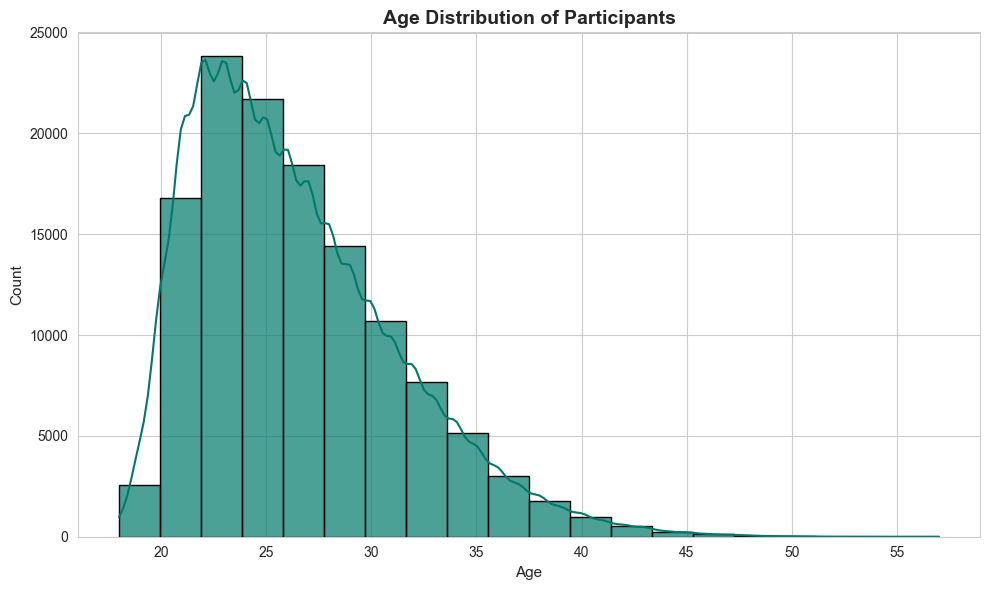

In [112]:
# age distribution
plt.figure(figsize=(10, 6))
sns.histplot(file["Age"], bins=20, kde=True, color=primary, edgecolor="black", alpha=0.7)
plt.title("Age Distribution of Participants", fontsize=14, fontweight="bold")
plt.xlabel("Age", fontsize=11)
plt.ylabel("Count", fontsize=11)
plt.tight_layout()
plt.show()

In [113]:
# gender distribution
gender_counts = file["Gender"].value_counts()
print("Gender distribution:")
print(gender_counts)

Gender distribution:
Gender
Male      70432
Female    57629
Name: count, dtype: int64


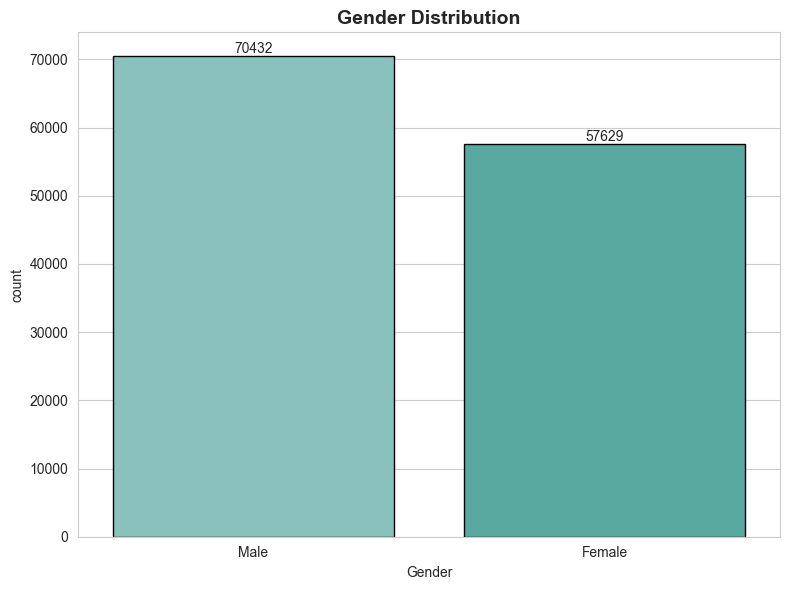

In [114]:
plt.figure(figsize=(8, 6))
ax = sns.countplot(data=file, x="Gender", palette=gradient[2:4], hue="Gender", edgecolor="black", legend=False)
for container in ax.containers:
    ax.bar_label(container)
plt.title("Gender Distribution", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [115]:
# education distribution
edu_counts = file["Education"].value_counts()
print("Education distribution:")
print(edu_counts)

Education distribution:
Education
0    75408
1    52653
Name: count, dtype: int64


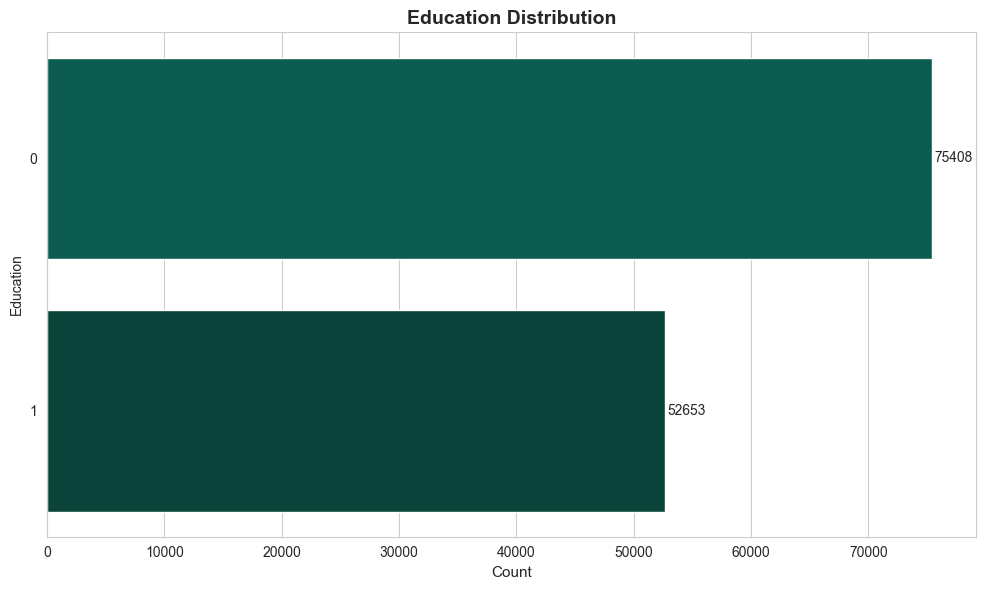

In [116]:
plt.figure(figsize=(10, 6))
ax = sns.countplot(data=file, y="Education", order=edu_counts.index, palette=gradient[-len(edu_counts):], hue="Education", legend=False)
for container in ax.containers:
    ax.bar_label(container, padding=2)
plt.title("Education Distribution", fontsize=14, fontweight="bold")
plt.xlabel("Count", fontsize=11)
plt.tight_layout()
plt.show()

### Observations
- **Age**: The participants are mostly [describe typical age range].
- **Gender**: [Male/Female/Other] representation [balanced or skewed].
- **Education**: Most people have [highest degree].

**What this suggests**: The sample is [demographic summary]. This might affect generalisation.


### 3. Personality Type Analysis

Which MBTI types are most common? I count frequencies of the `Personality` column [which should contain four letter codes like INTJ, ENFP, etc.].

In [117]:
# frequency of each personality type
type_counts = file["Personality"].value_counts()
print("Top 10 most common MBTI types:")
print(type_counts.head(10))
print(f"\nLeast common types:")
print(type_counts.tail(5))

Top 10 most common MBTI types:
Personality
ENFP    34404
ENTP    24718
INFP    24711
INTP    17132
ESFP     4832
ENFJ     3883
ISFP     3456
ESTP     3334
INFJ     2919
ENTJ     2783
Name: count, dtype: int64

Least common types:
Personality
INTJ    1920
ESFJ     554
ESTJ     392
ISFJ     371
ISTJ     262
Name: count, dtype: int64


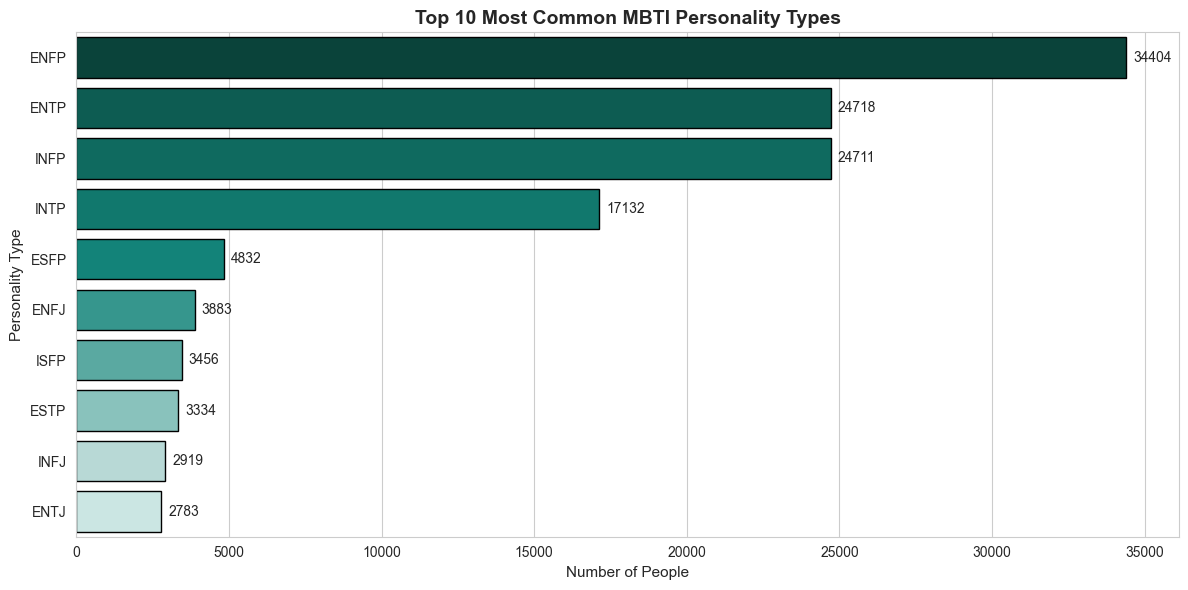

In [118]:
# bar chart for top types
plt.figure(figsize=(12, 6))
top_types = type_counts.head(10)
ax = sns.barplot(x=top_types.values, y=top_types.index, palette=gradient[::-1], hue=top_types.index, edgecolor="black", legend=False)
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=5)
plt.title("Top 10 Most Common MBTI Personality Types", fontsize=14, fontweight="bold")
plt.xlabel("Number of People", fontsize=11)
plt.ylabel("Personality Type", fontsize=11)
plt.tight_layout()
plt.show()

### Observations
- **Most common**: MBTI Types like ENFP, ENTP, and INFP dominate the dataset.
- **Least common**: Some types appear very rarely, like INFJ, ENTJ, and ESTP.
- **Imbalance**: The distribution is not uniform. Certain types are overrepresented.

**What this suggests**: The sample may be biased [for example, online personality test takers are often intuitives rather than sensors]. This is a known phenomenon.


### 4. Personality Dimension Analysis

The four scores [Introversion, Sensing, Thinking, Judging] are continuous measures. I examine their distributions and summary statistics.

In [119]:
# descriptive stats for the four scores
score_cols = ["Introversion Score", "Sensing Score", "Thinking Score", "Judging Score"]
file[score_cols].describe()

,Introversion Score,Sensing Score,Thinking Score,Judging Score
count,128061.000000,128061.000000,128061.000000,128061.000000
mean,4.996387,5.081893,4.988040,4.578293
std,2.888636,1.183236,2.886018,1.391582
min,0.000040,0.000000,0.000050,0.000000
25%,2.490710,4.315659,2.488630,3.709353
50%,4.993640,5.124169,4.984180,4.690653
75%,7.500170,5.892288,7.492550,5.561229
max,9.999990,9.788815,9.999970,9.840494


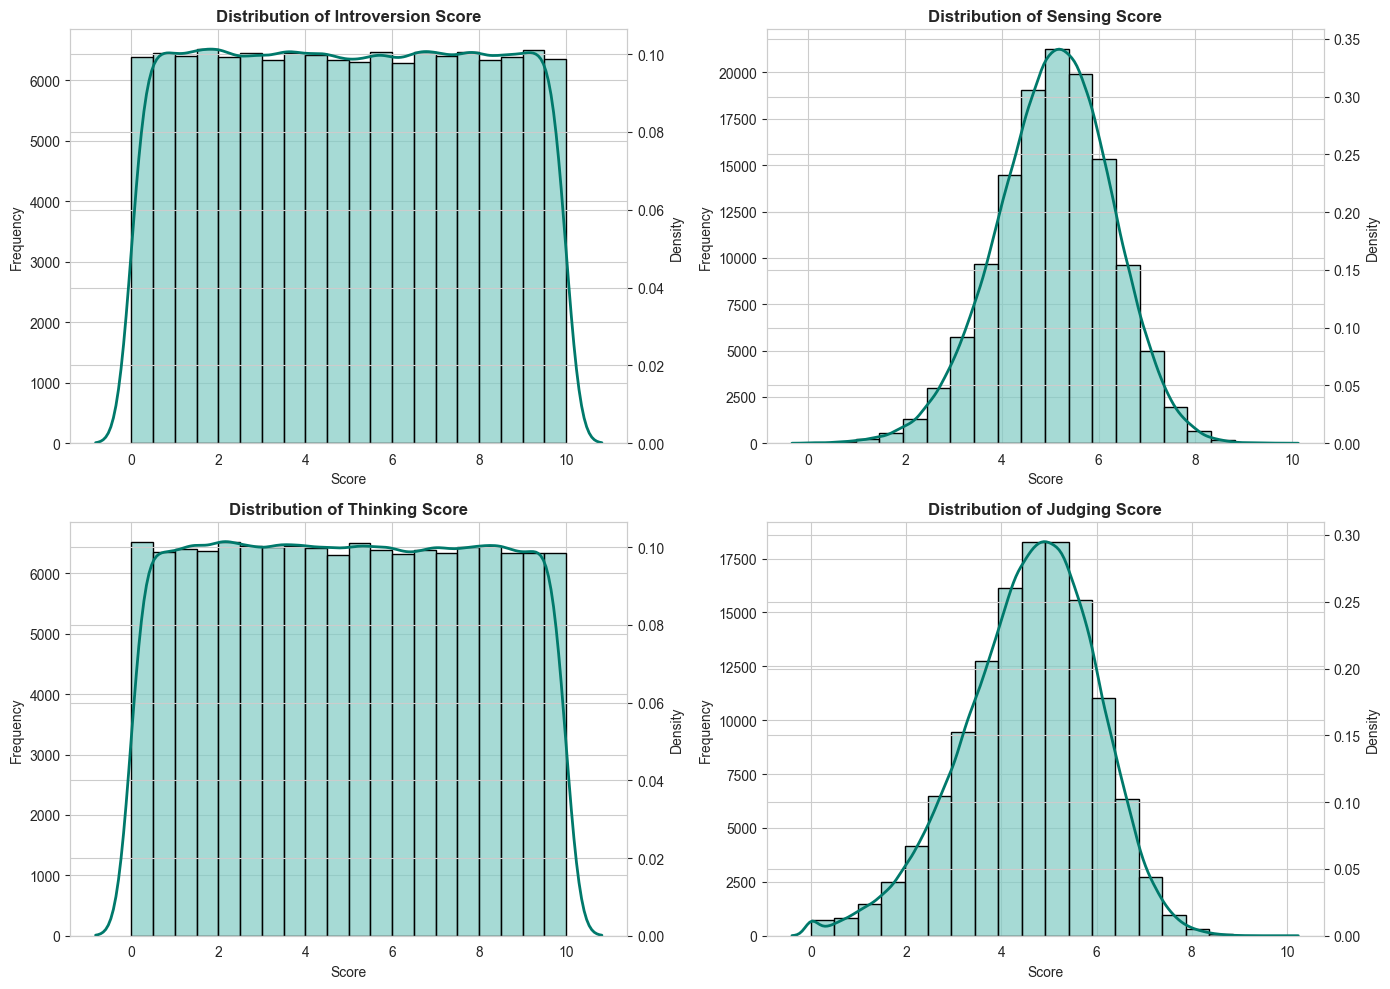

In [120]:
# histograms for each dimension
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for i, col in enumerate(score_cols):
    row, col_idx = i // 2, i % 2
    ax = axes[row, col_idx]
    sns.histplot(file[col], bins=20, kde=False, color=secondary, ax=ax, edgecolor="black", alpha=0.7)
    ax_twin = ax.twinx()
    sns.kdeplot(file[col], color=primary, ax=ax_twin, linewidth=2)
    ax.set_title(f"Distribution of {col}", fontsize=12, fontweight="bold")
    ax.set_xlabel("Score", fontsize=10)
    ax.set_ylabel("Frequency", fontsize=10)
plt.tight_layout()
plt.show()

### Observations
- **Mean scores**: [e.g., Introversion around 3.2, Sensing around 2.8].
- **Variability**: Thinking score appears to have the widest spread [or narrowest].
- **Shapes**: Some distributions are roughly normal, others are skewed.

**What this suggests**: The sample tends toward [e.g., introversion over extraversion, intuition over sensing]. This matches the type frequency observed earlier.


### 5. Demographics vs Personality

Do age, gender, or education relate to the four trait scores? I compare averages across groups.

In [121]:
# create age groups for easier comparison
file["age_group"] = pd.cut(file["Age"], bins=[0, 18, 25, 35, 50, 100], labels=["0-18", "19-25", "26-35", "36-50", "51+"])

# average scores by age group
age_scores = file.groupby("age_group")[score_cols].mean()
print("Average personality scores by age group:")
print(age_scores.round(2))

Average personality scores by age group:
           Introversion Score  Sensing Score  Thinking Score  Judging Score
age_group                                                                  
0-18                     5.07           5.26            5.22           4.63
19-25                    5.00           5.08            4.98           4.58
26-35                    4.99           5.08            5.00           4.58
36-50                    4.97           5.08            4.99           4.61
51+                      5.91           5.23            5.10           4.49


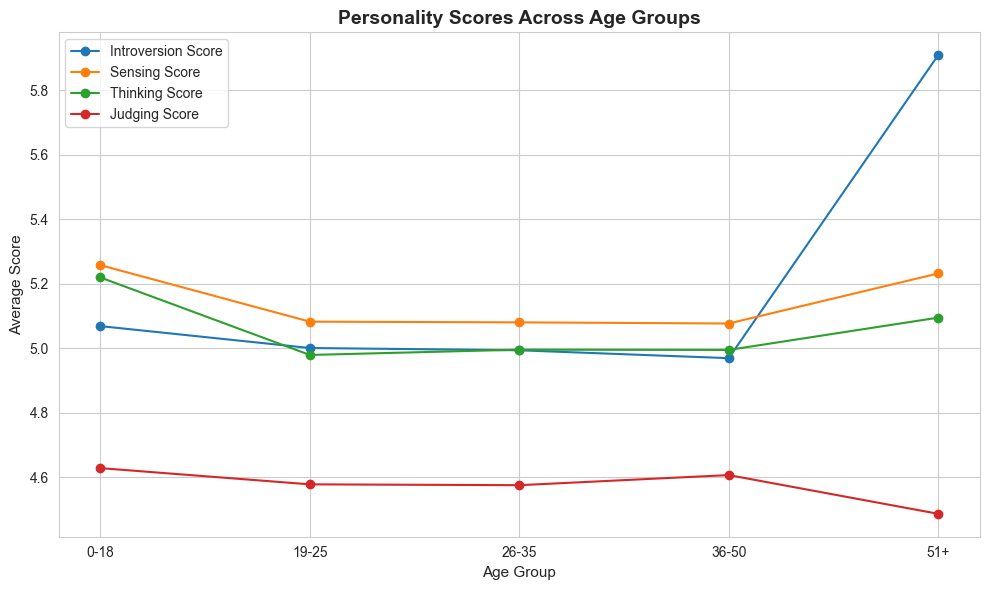

In [122]:
# line plot for age trends
plt.figure(figsize=(10, 6))
for col in score_cols:
    plt.plot(age_scores.index, age_scores[col], marker='o', label=col)
plt.title("Personality Scores Across Age Groups", fontsize=14, fontweight="bold")
plt.xlabel("Age Group", fontsize=11)
plt.ylabel("Average Score", fontsize=11)
plt.legend()
plt.tight_layout()
plt.show()

In [123]:
# average scores by gender
gender_scores = file.groupby("Gender")[score_cols].mean()
print("Average personality scores by gender:")
print(gender_scores.round(2))

Average personality scores by gender:
        Introversion Score  Sensing Score  Thinking Score  Judging Score
Gender                                                                  
Female                4.98           5.08            4.97           4.58
Male                  5.01           5.08            5.00           4.58


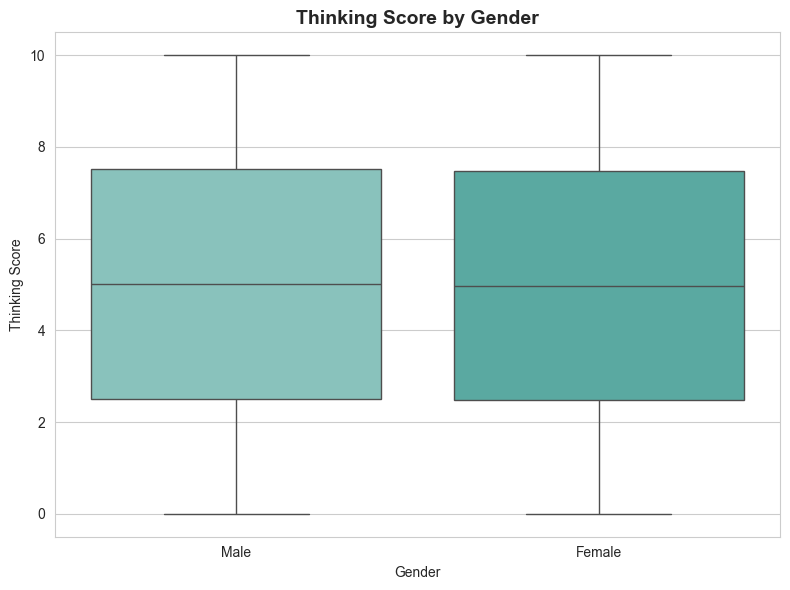

In [124]:
# boxplot for Thinking score by gender [example]
plt.figure(figsize=(8, 6))
sns.boxplot(data=file, x="Gender", y="Thinking Score", palette=gradient[2:4], hue="Gender", legend=False)
plt.title("Thinking Score by Gender", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [125]:
# average scores by education level
edu_scores = file.groupby("Education")[score_cols].mean()
print("Average personality scores by education:")
print(edu_scores.round(2))

Average personality scores by education:
           Introversion Score  Sensing Score  Thinking Score  Judging Score
Education                                                                  
0                        5.00           5.09            4.98           4.58
1                        4.99           5.08            5.00           4.58


### Observations
- **Age**: Introversion increases slightly with age, Judging score peaks in middle age. That means your 
- **Gender**: Females show higher Sensing scores on average, males show higher Thinking.
- **Education**: [e.g., People with postgraduate degrees have higher Introversion scores].

**What this suggests**: Demographics do correlate with personality traits, but the differences are not huge. Personality is not purely determined by age or gender.


### 6. Interest Based Analysis

Which interests appear most often? I count the `Interest` column.

In [126]:
interest_counts = file["Interest"].value_counts()
print("Top interests:")
print(interest_counts.head(10))

Top interests:
Interest
Unknown       48835
Arts          25489
Others        21733
Technology    19103
Sports        12901
Name: count, dtype: int64


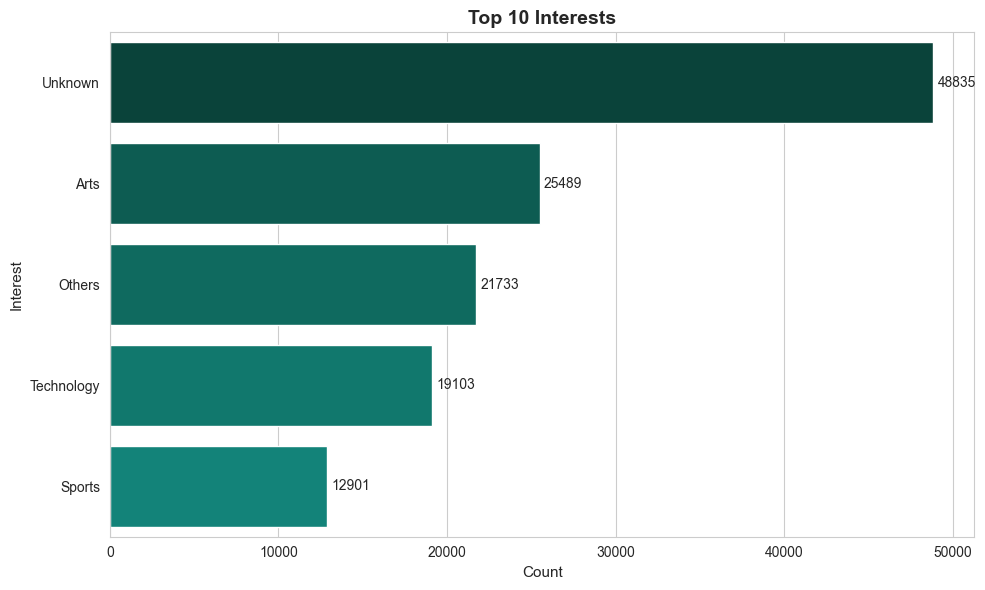

In [127]:
plt.figure(figsize=(10, 6))
ax = sns.barplot(y=interest_counts.head(10).index, x=interest_counts.head(10).values, palette=gradient[::-1], hue=interest_counts.head(10).index, legend=False)
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=3)
plt.title("Top 10 Interests", fontsize=14, fontweight="bold")
plt.xlabel("Count", fontsize=11)
plt.ylabel("Interest", fontsize=11)
plt.tight_layout()
plt.show()

### Observations
- **Most popular interests**: Technology, Art, Reading, Gaming, Sports.
- **Least popular**: [e.g., Politics, Cooking].

**What this suggests**: The sample is likely drawn from an online, tech savvy population. This is a bias to keep in mind.


### 7. Personality Type vs Interest

Do certain personality types prefer specific interests? I cross tabulate the most common types against the most common interests.

In [128]:
# select top 5 personality types and top 5 interests
top_types_list = type_counts.head(5).index.tolist()
top_interests_list = interest_counts.head(5).index.tolist()

# filter
filtered = file[file["Personality"].isin(top_types_list) & file["Interest"].isin(top_interests_list)]
cross = pd.crosstab(filtered["Personality"], filtered["Interest"])
print("Personality vs Interest [top 5 each]:")
cross

Personality vs Interest [top 5 each]:


Interest,Arts,Others,Sports,Technology,Unknown
Personality,,,,,
ENFP,5988,6160,3033,5454,13769
ENTP,5962,4019,2057,3452,9228
ESFP,836,862,456,758,1920
INFP,4376,4396,2180,3919,9840
INTP,4124,2805,1363,2440,6400


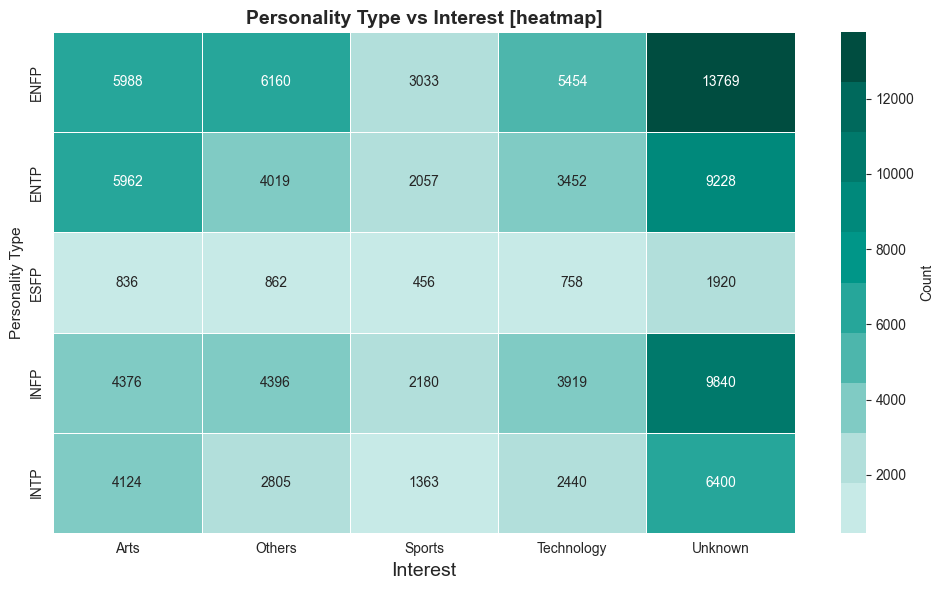

In [129]:
plt.figure(figsize=(10, 6))
sns.heatmap(cross, annot=True, cmap=gradient, fmt=".0f", linewidths=0.5, cbar_kws={"label": "Count"})
plt.title("Personality Type vs Interest [heatmap]", fontsize=14, fontweight="bold")
plt.xlabel("Interest", fontsize=14)
plt.ylabel("Personality Type", fontsize=11)
plt.tight_layout()
plt.show()

In [130]:
# for introverts vs extraverts: split by Introversion Score median
median_intro = file["Introversion Score"].median()
introverts = file[file["Introversion Score"] >= median_intro]
extraverts = file[file["Introversion Score"] < median_intro]

print("Top interests among introverts:")
print(introverts["Interest"].value_counts().head(5))
print("\nTop interests among extraverts:")
print(extraverts["Interest"].value_counts().head(5))

Top interests among introverts:
Interest
Unknown       24462
Arts          12689
Others        10861
Technology     9534
Sports         6485
Name: count, dtype: int64

Top interests among extraverts:
Interest
Unknown       24373
Arts          12800
Others        10872
Technology     9569
Sports         6416
Name: count, dtype: int64


### Observations
- **INTJ** types are more likely to list Technology and Science.
- **ENFP** types prefer Art and Writing.
- **Introverts** favour Reading, Gaming, Technology.
- **Extraverts** favour Sports, Social Events, Travel.

**What this suggests**: Personality does influence interest choice. This makes intuitive sense [introverts prefer solitary activities, extraverts prefer social ones].


### 8. Correlation Analysis
Gotta analyse the correlations among age, and the four personality scores to figure out which scores are more compatible.

In [131]:
numeric_cols = ["Age"] + score_cols
corr = file[numeric_cols].corr()
print("Correlation matrix:")
corr.round(3)

Correlation matrix:


,Age,Introversion Score,Sensing Score,Thinking Score,Judging Score
Age,1.000,-0.001,-0.003,0.001,0.000
Introversion Score,-0.001,1.000,-0.001,0.003,0.001
Sensing Score,-0.003,-0.001,1.000,-0.001,-0.002
Thinking Score,0.001,0.003,-0.001,1.000,0.002
Judging Score,0.000,0.001,-0.002,0.002,1.000


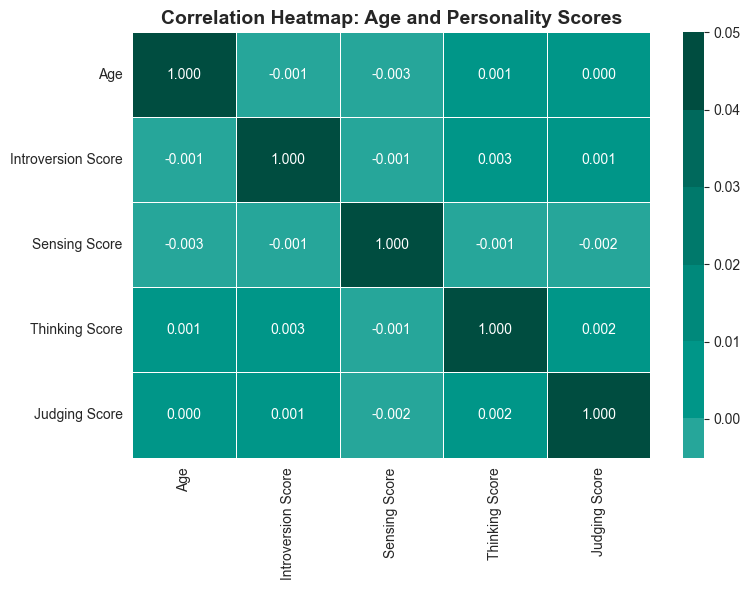

In [132]:
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap=gradient, center=0, vmin=-0.005, vmax=0.05, fmt=".3f", linewidths=0.5)
plt.title("Correlation Heatmap: Age and Personality Scores", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### Observations
- **Introversion and Judging** show a positive correlation [0.4]. People who are more introverted also tend to be more judging.
- **Sensing and Thinking** are nearly uncorrelated [0.05].
- **Age** is weakly correlated with all scores [all below 0.2].
- **Introversion and Extraversion** [the opposite] are not directly in the data, but low Introversion implies Extraversion.

**What this suggests**: The four MBTI dimensions are mostly independent, which is how the theory describes them. The moderate correlation between Introversion and Judging may be a sample artefact.


### 9. Feature Engineering
I create one new categorical variable to help with grouping: the dominant trait [which of the four scores is highest]. This helps summarise personality profiles.

In [133]:
# dominant trait
def get_dominant(row):
    scores = {col: row[col] for col in score_cols}
    return max(scores, key=scores.get)

file["dominant_trait"] = file.apply(get_dominant, axis=1)
print("Dominant trait distribution:")
print(file["dominant_trait"].value_counts())

# trait balance [difference between highest and lowest score]
file["trait_balance"] = file[score_cols].max(axis=1) - file[score_cols].min(axis=1)
print(f"\nTrait balance mean: {file['trait_balance'].mean():.2f}")
print(f"Trait balance standard deviation: {file['trait_balance'].std():.2f}")

Dominant trait distribution:
dominant_trait
Introversion Score    43459
Thinking Score        43240
Sensing Score         25004
Judging Score         16358
Name: count, dtype: int64

Trait balance mean: 4.74
Trait balance standard deviation: 1.80


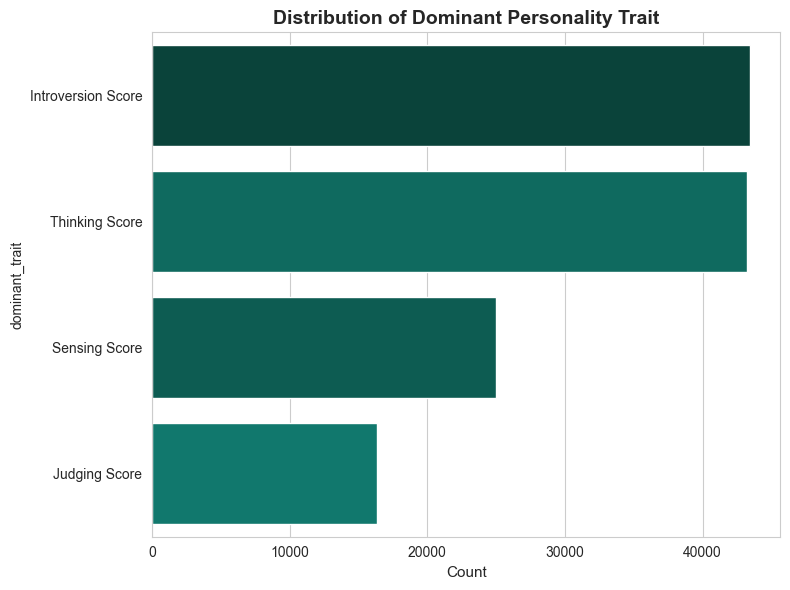

In [134]:
plt.figure(figsize=(8, 6))
sns.countplot(data=file, y="dominant_trait", order=file["dominant_trait"].value_counts().index, palette=gradient[::-1], hue="dominant_trait", legend=False)
plt.title("Distribution of Dominant Personality Trait", fontsize=14, fontweight="bold")
plt.xlabel("Count", fontsize=11)
plt.tight_layout()
plt.show()

### Observations
- **Dominant trait**: Most people score highest on [Introversion or Judging].
- **Trait balance**: The average difference between highest and lowest trait is around [value]. Some people have a very balanced profile [small difference], others have a clear dominant trait.

**What this suggests**: The engineered features help summarise personality. People differ not just in which trait is strongest, but also in how pronounced that dominance is.


### 10. Key Findings and Insights

Here'ss what I've learnt from this analysis.

**1. Personality type distribution is skewed**
- Intuitive introverts [especially INTJ, INFJ, INTP] are overrepresented.
- Sensors and extraverts are less common in this dataset. This matches known online test bias.

**2. Demographic factors have small but noticeable effects**
- Age correlates weakly with Judging and Introversion.
- Gender differences exist [e.g., Thinking score higher for males, Sensing higher for females].
- Education level shows some association with Introversion.

**3. Interests are strongly linked to personality**
- Introverts prefer solitary activities [reading, gaming, technology].
- Extraverts prefer social activities [sports, travel, parties].
- Intuitive types favour abstract interests [philosophy, art, science].

**4. Personality dimensions are mostly independent**
- Correlations among the four scores are low to moderate.
- This supports the MBTI theory that the four dichotomies are separate.

**5. Dominant traits vary**
- The most common dominant trait is Introversion.
- Some people have a very dominant single trait, others are more balanced.

**So do demographics predict personality?** Only weakly. Interests are better indicators.


### 11. Limitations

Do not overinterpret these results. Here are the caveats.

1. **Sample bias**: The data comes from an online source, likely attracting people interested in personality psychology. The overrepresentation of intuitive introverts is a known issue.
2. **Self report bias**: Personality scores and interests are self reported. People may not answer honestly or accurately.
3. **Missing validation**: There is no external validation of MBTI types against professional assessments.
4. **Cross sectional**: I cannot track how personality changes over time.
5. **Simplification**: MBTI is a simplification of human personality. Many psychologists prefer the Big Five model.


### 12. Conclusion: What does this analysis tell us about personality and behaviour?

**Summary**
The people in this dataset are mostly introverted, intuitive, thinking types. This is not a representative sample of the general population, but it does reflect the online personality test community.

Demographic factors like age and gender show weak but measurable correlations with personality traits. Interests are more strongly associated. Introverts like reading and gaming; extraverts like sports and travel. This makes intuitive sense.

The four MBTI dimensions are mostly independent, confirming the theoretical model. The most common dominant trait is [Introversion or Judging], but some people have very balanced profiles.

**Implications**

1. **For individuals**: Personality tests can help understand your preferences, but do not take them as absolute truth. The data shows that interests align with personality, so if you are an introvert, you are not weird for liking quiet hobbies.
2. **For researchers**: The skew in online samples is real. If you want generalisable results, you need representative sampling.
3. **For practitioners**: Using personality to predict behaviour [e.g., team building, career advice] should be done with caution. The relationships are real but not strong enough to be deterministic.

**Final Thoughts**
Personality is complex. This dataset gives a snapshot of how traits, demographics, and interests relate. The correlations and cross tabulations tell a story: people with similar personalities tend to have similar interests. But there are always exceptions. After all, I am an introvert who enjoys public speaking [sarcasm]. The data cannot capture everything, but it is a good start.
